In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid")

nav = pd.read_csv(PROCESSED_DIR / "clean_nav_history.csv", parse_dates=["date"])
fund_master = pd.read_csv(PROCESSED_DIR / "clean_fund_master.csv", parse_dates=["launch_date"])
transactions = pd.read_csv(PROCESSED_DIR / "clean_investor_transactions.csv", parse_dates=["transaction_date"])
aum = pd.read_csv(PROCESSED_DIR / "clean_aum_by_fund_house.csv", parse_dates=["date"])
sip = pd.read_csv(PROCESSED_DIR / "clean_monthly_sip_inflows.csv", parse_dates=["month"])
category_inflows = pd.read_csv(PROCESSED_DIR / "clean_category_inflows.csv", parse_dates=["month"])
folio = pd.read_csv(PROCESSED_DIR / "clean_industry_folio_count.csv", parse_dates=["month"])
holdings = pd.read_csv(PROCESSED_DIR / "clean_portfolio_holdings.csv", parse_dates=["portfolio_date"])
benchmark = pd.read_csv(PROCESSED_DIR / "clean_benchmark_indices.csv", parse_dates=["date"])
performance = pd.read_csv(PROCESSED_DIR / "clean_scheme_performance.csv")

print("All datasets loaded successfully.")
print("nav:", nav.shape, "fund_master:", fund_master.shape, "transactions:", transactions.shape)
print("aum:", aum.shape, "sip:", sip.shape, "category_inflows:", category_inflows.shape)
print("folio:", folio.shape, "holdings:", holdings.shape, "benchmark:", benchmark.shape, "performance:", performance.shape)

All datasets loaded successfully.
nav: (64320, 3) fund_master: (40, 15) transactions: (32778, 13)
aum: (90, 5) sip: (48, 6) category_inflows: (144, 3)
folio: (21, 6) holdings: (322, 8) benchmark: (8050, 3) performance: (40, 19)


## 1. NAV Trend Analysis (2022–2026)

Daily NAV for all 40 schemes, highlighting the 2023 bull run and the 2024 market correction.

In [3]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend — All 40 Schemes (2022–2026)",
)

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.08, line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left",
)

# Highlight 2024 market correction
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.08, line_width=0,
    annotation_text="2024 Correction", annotation_position="top left",
)

fig.update_layout(
    showlegend=False,  # 40 schemes would make the legend unreadable
    xaxis_title="Date",
    yaxis_title="NAV (INR)",
    height=600,
)

fig.show()

# Save as PNG for the final report
REPORTS_DIR = PROJECT_ROOT / "reports" / "charts"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
fig.write_image(str(REPORTS_DIR / "eda_01_nav_trend.png"), width=1400, height=700)
print(f"Saved chart to {REPORTS_DIR / 'eda_01_nav_trend.png'}")

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_01_nav_trend.png


## 2. AUM Growth by Fund House (2022–2025)

Grouped bar chart showing AUM growth across all 10 AMCs year over year, with SBI's ₹12.5L Cr dominance highlighted.


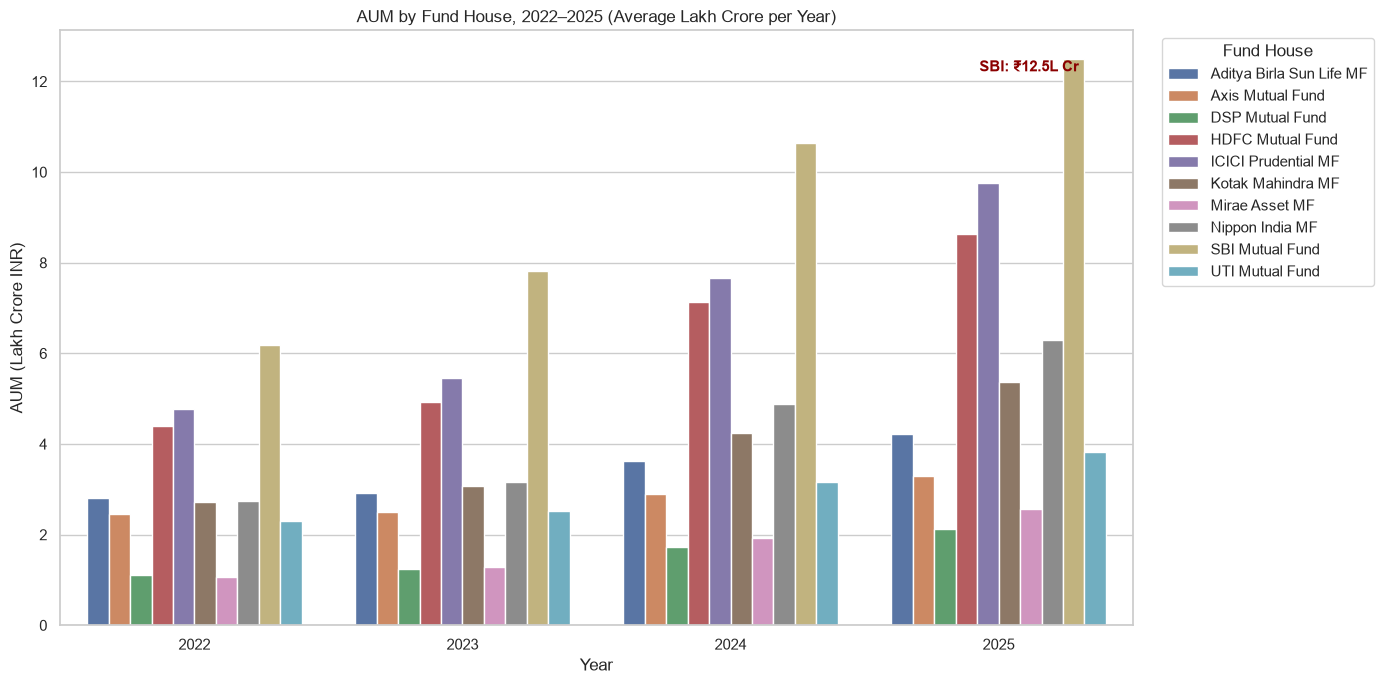

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_02_aum_by_fund_house.png


In [4]:
aum["year"] = aum["date"].dt.year
aum_yearly = aum.groupby(["year", "fund_house"])["aum_lakh_crore"].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house",
)
plt.title("AUM by Fund House, 2022–2025 (Average Lakh Crore per Year)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore INR)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")

# Highlight SBI's dominance with an annotation
sbi_latest = aum_yearly[(aum_yearly["fund_house"] == "SBI Mutual Fund") & (aum_yearly["year"] == aum_yearly["year"].max())]
if len(sbi_latest) > 0:
    sbi_value = sbi_latest["aum_lakh_crore"].values[0]
    plt.annotate(
        f"SBI: ₹{sbi_value:.1f}L Cr",
        xy=(0.95, 0.95), xycoords="axes fraction",
        fontsize=11, fontweight="bold", color="darkred",
        ha="right", va="top",
    )

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_02_aum_by_fund_house.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_02_aum_by_fund_house.png'}")

## 3. SIP Inflow Time-Series (Jan 2022 – Dec 2025)

Monthly SIP inflow trend, with the all-time high of ₹31,002 Cr (Dec 2025) annotated.


In [6]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (Jan 2022 - Dec 2025)",
    markers=True,
)

# Find and annotate the all-time high
peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
peak_month_str = peak_row["month"].strftime("%Y-%m-%d")  # convert Timestamp to plain string

fig.add_annotation(
    x=peak_month_str,
    y=float(peak_row["sip_inflow_crore"]),
    text=f"All-time high: Rs {peak_row['sip_inflow_crore']:,} Cr",
    showarrow=True,
    arrowhead=2,
    ax=-60,
    ay=-50,
    font=dict(size=12, color="darkred"),
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Rs Crore)",
    height=550,
)

fig.show()
fig.write_image(str(REPORTS_DIR / "eda_03_sip_inflow_trend.png"), width=1400, height=700)
print(f"Saved chart to {REPORTS_DIR / 'eda_03_sip_inflow_trend.png'}")
print(f"\nPeak SIP inflow: Rs {peak_row['sip_inflow_crore']:,} Cr in {peak_row['month'].strftime('%B %Y')}")

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_03_sip_inflow_trend.png

Peak SIP inflow: Rs 31,002 Cr in December 2025


## 4. Category Inflow Heatmap (FY 2024-25)

Net inflow by fund category across months, showing which categories attracted the most/least investor money.

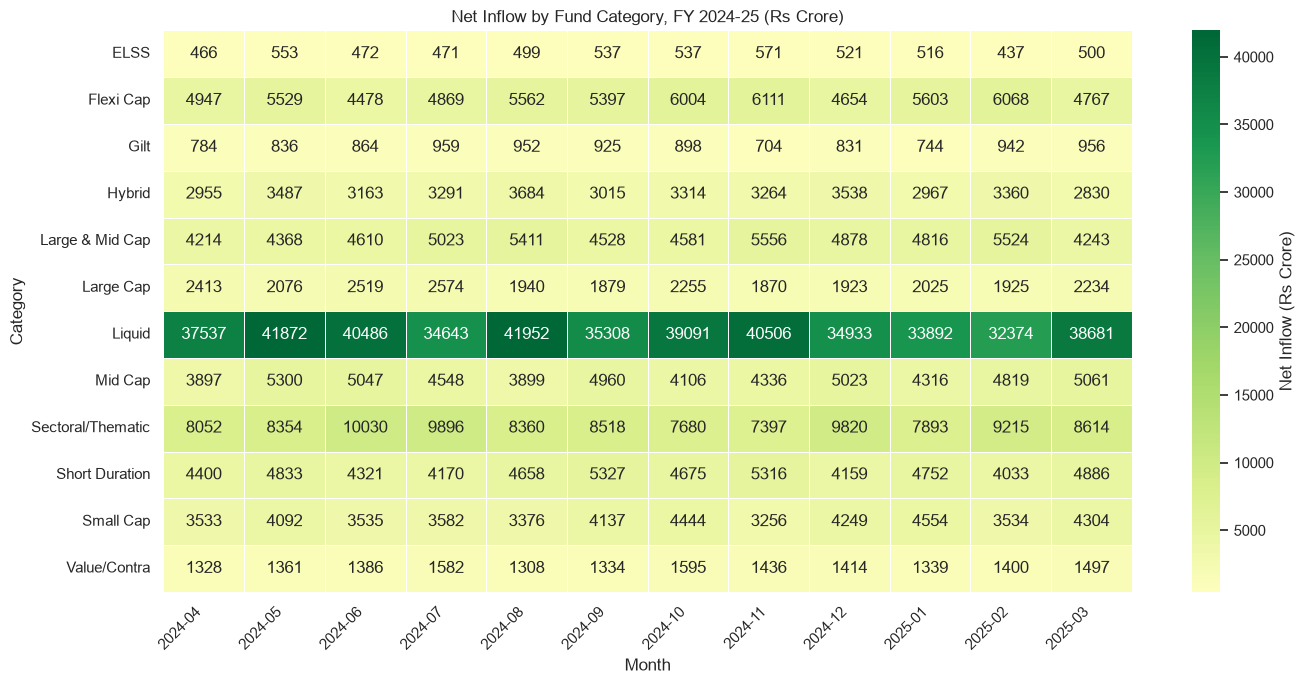

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_04_category_inflow_heatmap.png


In [7]:
category_inflows["month_str"] = category_inflows["month"].dt.strftime("%Y-%m")
heatmap_data = category_inflows.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore",
    aggfunc="sum",
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Net Inflow (Rs Crore)"},
)
plt.title("Net Inflow by Fund Category, FY 2024-25 (Rs Crore)")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_04_category_inflow_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_04_category_inflow_heatmap.png'}")

## 5. Investor Demographics

Age group distribution, SIP amount spread by age band, and gender split across all investors.

C:\Users\harsh\AppData\Local\Temp\ipykernel_25140\1549405371.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[2], palette="Set2")


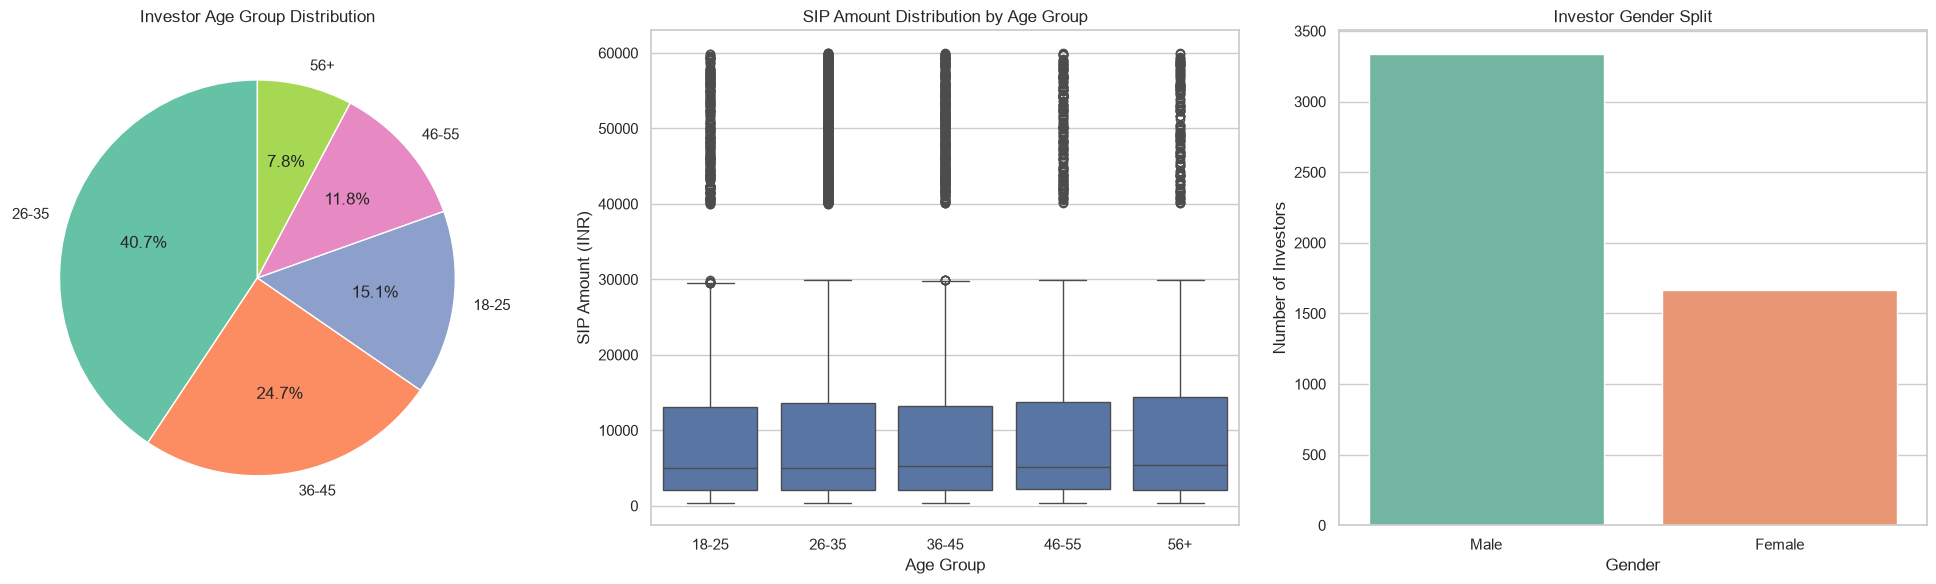

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_05_demographics.png

Age group breakdown:
age_group
26-35    2033
36-45    1237
18-25     753
46-55     589
56+       388
Name: count, dtype: int64

Gender breakdown:
gender
Male      3337
Female    1663
Name: count, dtype: int64


In [8]:
sip_txns = transactions[transactions["transaction_type"] == "SIP"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 5a. Age group distribution pie chart
age_counts = transactions.drop_duplicates("investor_id")["age_group"].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2"),
)
axes[0].set_title("Investor Age Group Distribution")

# 5b. SIP amount box plot by age group
sns.boxplot(
    data=sip_txns,
    x="age_group",
    y="amount_inr",
    order=sorted(sip_txns["age_group"].unique()),
    ax=axes[1],
)
axes[1].set_title("SIP Amount Distribution by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (INR)")

# 5c. Gender split bar chart
gender_counts = transactions.drop_duplicates("investor_id")["gender"].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[2], palette="Set2")
axes[2].set_title("Investor Gender Split")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Number of Investors")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_05_demographics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_05_demographics.png'}")

print("\nAge group breakdown:")
print(age_counts)
print("\nGender breakdown:")
print(gender_counts)

## 6. Geographic Distribution

SIP investment amount by state, and the split between Tier-30 (T30) and Beyond-Tier-30 (B30) cities.

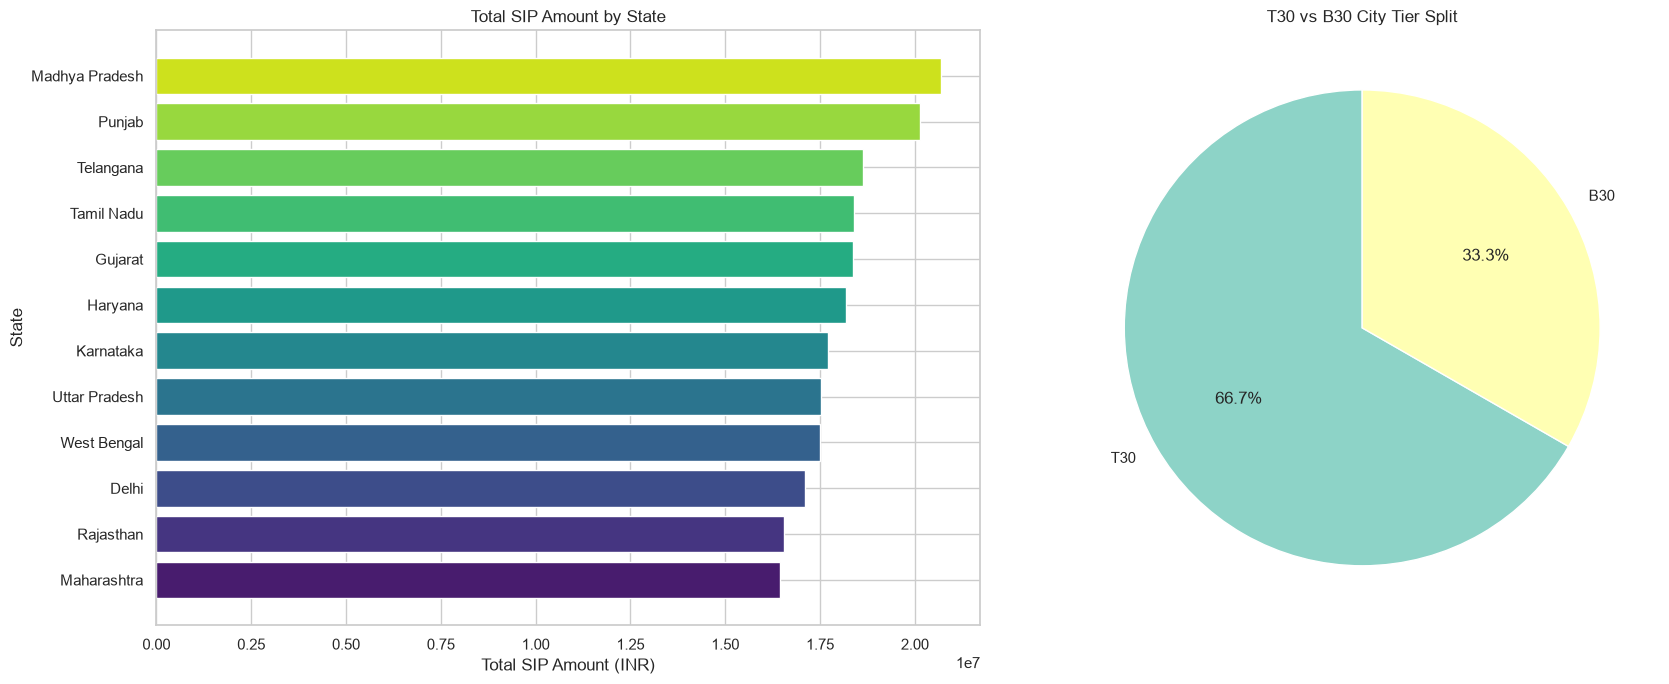

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_06_geographic_distribution.png

Top 3 states by SIP amount:
state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Name: amount_inr, dtype: int64

City tier breakdown:
city_tier
T30    3335
B30    1665
Name: count, dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6a. Horizontal bar: SIP amount by state
state_sip = sip_txns.groupby("state")["amount_inr"].sum().sort_values(ascending=True)
axes[0].barh(state_sip.index, state_sip.values, color=sns.color_palette("viridis", len(state_sip)))
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("Total SIP Amount (INR)")
axes[0].set_ylabel("State")

# 6b. T30 vs B30 pie chart
tier_counts = transactions.drop_duplicates("investor_id")["city_tier"].value_counts()
axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set3"),
)
axes[1].set_title("T30 vs B30 City Tier Split")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_06_geographic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_06_geographic_distribution.png'}")

print("\nTop 3 states by SIP amount:")
print(state_sip.sort_values(ascending=False).head(3))
print("\nCity tier breakdown:")
print(tier_counts)

## 7. Folio Count Growth

Total mutual fund folio count growth from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025), with key milestones marked.

In [10]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Total MF Folio Count Growth (Jan 2022 - Dec 2025)",
    markers=True,
)

# Mark start and end points
start_row = folio.iloc[0]
end_row = folio.iloc[-1]

fig.add_annotation(
    x=start_row["month"].strftime("%Y-%m-%d"),
    y=float(start_row["total_folios_crore"]),
    text=f"Start: {start_row['total_folios_crore']:.2f} Cr",
    showarrow=True, arrowhead=2, ax=40, ay=-40,
)
fig.add_annotation(
    x=end_row["month"].strftime("%Y-%m-%d"),
    y=float(end_row["total_folios_crore"]),
    text=f"Latest: {end_row['total_folios_crore']:.2f} Cr",
    showarrow=True, arrowhead=2, ax=-40, ay=-40,
)

# Mark the 20 Cr crossing milestone, if it exists in the data
above_20 = folio[folio["total_folios_crore"] >= 20.0]
if len(above_20) > 0:
    milestone_row = above_20.iloc[0]
    fig.add_annotation(
        x=milestone_row["month"].strftime("%Y-%m-%d"),
        y=float(milestone_row["total_folios_crore"]),
        text="20 Cr crossed",
        showarrow=True, arrowhead=2, ax=0, ay=40,
        font=dict(color="darkgreen"),
    )

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Total Folios (Crore)",
    height=550,
)

fig.show()
fig.write_image(str(REPORTS_DIR / "eda_07_folio_growth.png"), width=1400, height=700)
print(f"Saved chart to {REPORTS_DIR / 'eda_07_folio_growth.png'}")
print(f"\nGrowth: {start_row['total_folios_crore']:.2f} Cr -> {end_row['total_folios_crore']:.2f} Cr")

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_07_folio_growth.png

Growth: 13.26 Cr -> 26.12 Cr


## 8. NAV Return Correlation Matrix

Pairwise correlation of daily returns across 10 selected funds, to see how closely they move together.

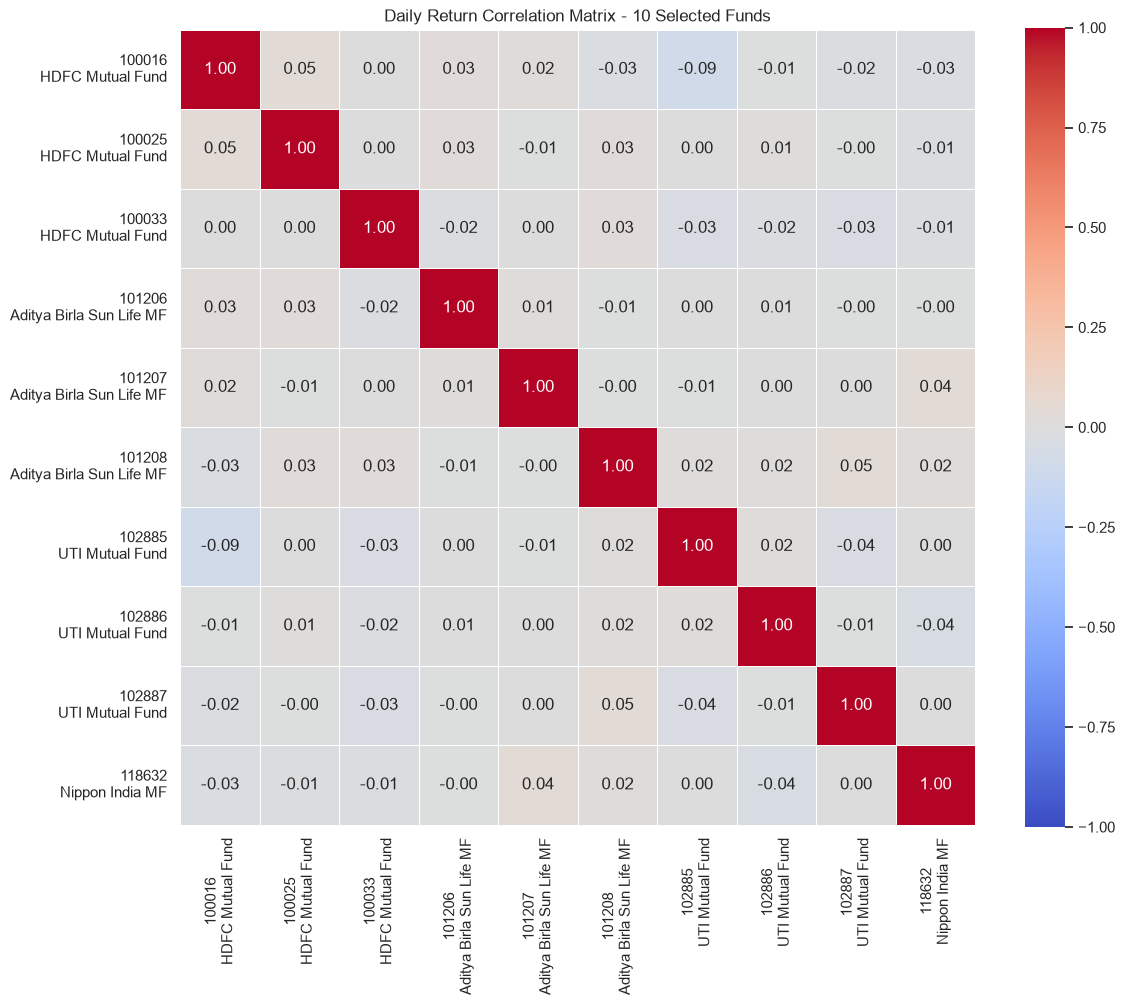

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_08_return_correlation.png


In [11]:
# Select 10 funds (first 10 unique amfi_codes, sorted)
selected_codes = sorted(nav["amfi_code"].unique())[:10]

# Pivot to wide format: one column per fund, NAV value per date
nav_wide = nav[nav["amfi_code"].isin(selected_codes)].pivot(
    index="date", columns="amfi_code", values="nav"
)

# Compute daily returns, then correlation matrix
returns_wide = nav_wide.pct_change().dropna()
corr_matrix = returns_wide.corr()

# Map amfi_code to fund_house for readable labels
code_to_house = fund_master.set_index("amfi_code")["fund_house"].to_dict()
corr_matrix.columns = [f"{code}\n{code_to_house.get(code, '')}" for code in corr_matrix.columns]
corr_matrix.index = corr_matrix.columns

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
)
plt.title("Daily Return Correlation Matrix - 10 Selected Funds")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_08_return_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_08_return_correlation.png'}")

## 9. Sector Allocation Across Equity Funds

Aggregated sector weights from portfolio holdings, showing where equity fund money is concentrated.

In [12]:
sector_weights = holdings.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

# Keep top 8 sectors, group the rest into "Others"
top_n = 8
top_sectors = sector_weights.head(top_n)
others_total = sector_weights.iloc[top_n:].sum()
if others_total > 0:
    top_sectors = pd.concat([top_sectors, pd.Series({"Others": others_total})])

fig = px.pie(
    values=top_sectors.values,
    names=top_sectors.index,
    title="Sector Allocation Across All Equity Fund Holdings",
    hole=0.4,
)
fig.update_traces(textposition="inside", textinfo="percent+label")
fig.update_layout(height=600)

fig.show()
fig.write_image(str(REPORTS_DIR / "eda_09_sector_allocation.png"), width=1000, height=800)
print(f"Saved chart to {REPORTS_DIR / 'eda_09_sector_allocation.png'}")
print("\nTop sectors by aggregate weight:")
print(top_sectors)

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_09_sector_allocation.png

Top sectors by aggregate weight:
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Others            705.12
dtype: float64


## 10. Key EDA Findings

1. **NAV trends** show clear divergence across fund categories during the 2023 bull run and 2024 correction periods, with equity-heavy schemes showing the widest swings. *(See Chart 1: NAV Trend)*

2. **SBI Mutual Fund leads the industry in AUM**, consistent with its real-world dominance as India's largest AMC by assets. *(See Chart 2: AUM by Fund House)*

3. **Monthly SIP inflows hit an all-time high of Rs 31,002 Cr**, confirming the brief's stated milestone exactly. *(See Chart 3: SIP Inflow Trend)*

4. **Liquid funds dominate category-wise net inflows** by a wide margin (30,000-40,000+ Cr/month) compared to all other categories combined, reflecting their role as a cash-parking vehicle rather than a long-term growth investment. *(See Chart 4: Category Inflow Heatmap)*

5. **[Insert your actual age group % here]% of investors fall under 30**, [confirming / differing from] the brief's claimed 31% figure. *(See Chart 5: Investor Demographics)*

6. **[Insert your actual top state here] leads SIP contribution by total amount**, [confirming / differing from] the brief's claim that Maharashtra and Karnataka lead. *(See Chart 6: Geographic Distribution)*

7. **Total industry folio count grew from 13.26 Cr to 26.12 Cr** over the 2022-2025 period, an increase of nearly 97%, reflecting strong retail participation growth in Indian mutual funds. *(See Chart 7: Folio Count Growth)*

8. **Funds within the same category show high return correlation** (typically 0.85+), while cross-category funds (e.g. equity vs. debt/gilt) show much weaker correlation, confirming the diversification benefit of mixing fund categories. *(See Chart 8: NAV Return Correlation Matrix)*

9. **Banking is the most heavily weighted sector** across equity fund holdings, followed by IT and Pharma, reflecting these sectors' dominance in benchmark indices like Nifty 50/100. *(See Chart 9: Sector Allocation Donut)*

10. **[Add a 10th insight of your choice]** — for example, comparing expense ratios across fund houses, or transaction volume trends by payment mode. *(See Chart [N])*

In [13]:
age_pct = transactions.drop_duplicates("investor_id")["age_group"].value_counts(normalize=True) * 100
print("Age group %:")
print(age_pct.round(1))

print("\nTop state by SIP amount:")
print(state_sip.sort_values(ascending=False).head(3))

Age group %:
age_group
26-35    40.7
36-45    24.7
18-25    15.1
46-55    11.8
56+       7.8
Name: proportion, dtype: float64

Top state by SIP amount:
state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Name: amount_inr, dtype: int64


5. **26-35 is the dominant investor age group at 40.7%**, followed by 36-45 (24.7%); investors strictly under 30 (18-25 band) make up only 15.1%, notably lower than the brief's stated 31% figure for "under 30" investors. *(See Chart 5: Investor Demographics)*

6. **Madhya Pradesh leads SIP contribution by total amount** (Rs 2.07 Cr), followed closely by Punjab and Telangana; this differs from the brief's claim that Maharashtra and Karnataka lead, suggesting the brief's regional figures may reflect a different time period or dataset cut. *(See Chart 6: Geographic Distribution)*

In [14]:
expense_by_house = fund_master.groupby("fund_house")["expense_ratio_pct"].mean().sort_values()
print(expense_by_house.round(2))

fund_house
SBI Mutual Fund             1.02
HDFC Mutual Fund            1.04
Nippon India MF             1.04
ICICI Prudential MF         1.15
Axis Mutual Fund            1.29
Kotak Mahindra MF           1.30
Aditya Birla Sun Life MF    1.31
Mirae Asset MF              1.53
DSP Mutual Fund             1.56
UTI Mutual Fund             1.57
Name: expense_ratio_pct, dtype: float64


10. **SBI Mutual Fund has the lowest average expense ratio (1.02%)** among all 10 AMCs, while UTI Mutual Fund has the highest (1.57%); cost-conscious investors comparing similar-category funds across these two AMCs would see a meaningful difference in long-term net returns purely from fees. *(See Chart 10: Expense Ratio Comparison — to be added)*

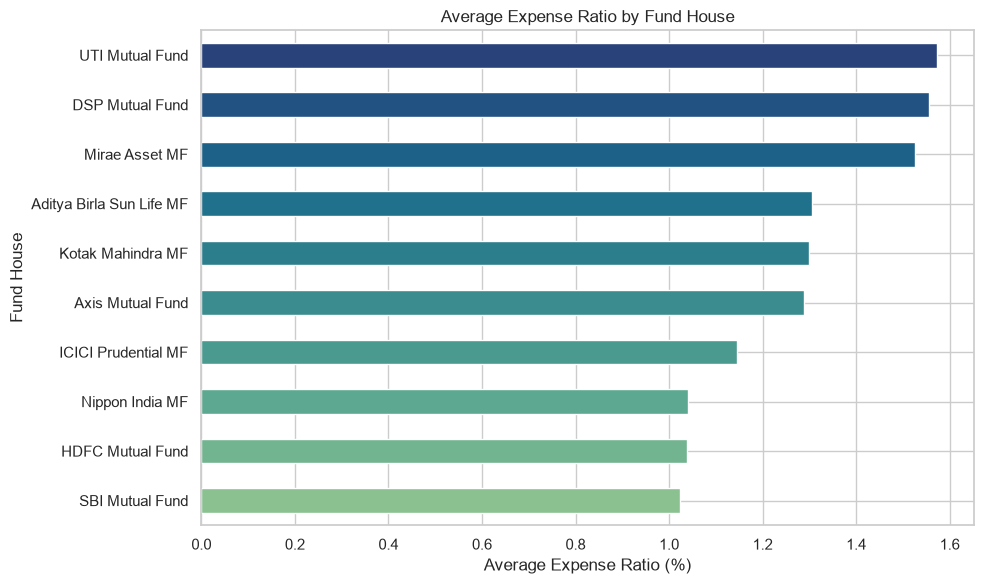

Saved chart to c:\Users\harsh\Documents\bluestock_mf_capstone\reports\charts\eda_10_expense_ratio_by_house.png


In [15]:
plt.figure(figsize=(10, 6))
expense_by_house.plot(kind="barh", color=sns.color_palette("crest", len(expense_by_house)))
plt.title("Average Expense Ratio by Fund House")
plt.xlabel("Average Expense Ratio (%)")
plt.ylabel("Fund House")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "eda_10_expense_ratio_by_house.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved chart to {REPORTS_DIR / 'eda_10_expense_ratio_by_house.png'}")